# Module 2 · Part B — Predictive modeling (`02_modeling.ipynb`)

This continues directly from `01_eda.ipynb`:

* It reads the **same committed `titanic.csv`** that `01_eda.ipynb` saved (no second `sns.load_dataset` call).
* It applies the **same rule-based cleaning** (`basic_clean` from `titanic_cleaning.py`: drop the 2 rows missing `embarked`, `deck` → `"Unknown"`).
* Anything that is *learned* from data (age imputation value, scaling mean/std, one-hot categories) happens **inside a scikit-learn `Pipeline` fitted on the training split only**.

| Task | Section |
|---|---|
| 7 Stratified split | §1 |
| 8 Leak-free preprocessing | §2 |
| 9 Three classifiers + `plot_tree` | §3 |
| 10 Full metric suite side by side | §4 |
| 11 Imbalance: baseline vs `class_weight` vs SMOTE | §5 |
| 12 GridSearchCV + OOB score | §6 |
| 13 Regression side-task (fare) | §7 |
| 14 Comparison table + recommendation | §8 |
| 15 Save / reload the full pipeline | §9 |

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             mean_absolute_error, mean_squared_error, precision_score, r2_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from titanic_cleaning import basic_clean

RANDOM_STATE = 42
pd.set_option("display.width", 140)

# ---- one consistent chart style for the whole module ----
FEMALE, MALE = "#2a78d6", "#eb6834"          # colour always follows the entity
SURVIVED, DIED = "#1baf7a", "#898781"
SEX_COLORS = {"female": FEMALE, "male": MALE}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.edgecolor": "#898781", "axes.labelcolor": "#52514e", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.titleweight": "bold", "axes.titlesize": 12,
})
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

## 0. Continue from the saved data

In [2]:
raw = pd.read_csv("titanic.csv")          # the file 01_eda.ipynb produced — not a new download
df = basic_clean(raw)                     # same rule-based cleaning as in the EDA notebook
print("Rows after rule-based cleaning:", len(df))
print("Missing values still present (to be handled inside the pipeline):")
print(df.isna().sum()[df.isna().sum() > 0])

Rows after rule-based cleaning: 889
Missing values still present (to be handled inside the pipeline):
age    177
dtype: int64


## 1. Stratified train/test split (Task 7)

**Features used:** `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked` — the raw passenger facts.
**Left out on purpose:** `alive` (it *is* the target written as text — pure leakage), `class`/`who`/`adult_male`/`alone`/`embark_town` (just re-codings of columns we already use), `deck` (77 % “Unknown”).

**Why stratify?** The classes are imbalanced: about **62 % died and 38 % survived**. A purely random 80/20 split could, by chance, put a different share of survivors in the test set than in the training set, so the test score would partly measure luck. `stratify=y` keeps the same 62/38 ratio in both parts, so the model trains and is tested on the same kind of population. The split happens **before any preprocessing**.

In [3]:
FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
TARGET = "survived"
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

split_check = pd.DataFrame({
    "rows": [len(y), len(y_train), len(y_test)],
    "survived %": [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
}, index=["full data", "train", "test"]).round(2)
split_check

,rows,survived %
full data,889,38.25
train,711,38.26
test,178,38.20


## 2. Leak-free preprocessing with `ColumnTransformer` + `Pipeline` (Task 8)

| Columns | Step 1 | Step 2 |
|---|---|---|
| numeric: `pclass`, `age`, `sibsp`, `parch`, `fare` | `SimpleImputer(strategy="median")` (only `age` actually has gaps) | `StandardScaler()` |
| categorical: `sex`, `embarked` | `SimpleImputer(strategy="most_frequent")` (safety net for new data) | `OneHotEncoder(handle_unknown="ignore")` |

**My imputation choice here:** a plain training-set median for `age`. It differs from the EDA's sex × class median — the assignment allows that — because a single-column imputer is simpler to run safely inside a pipeline, and the model can still learn class and sex effects from the other columns.

**Why a Pipeline prevents leakage:** when `pipeline.fit(X_train, y_train)` runs, every step calls `fit` on the **training rows only**. When `pipeline.predict(X_test)` runs, the same steps only call `transform` with the numbers they learned from training. The test set is never used to learn anything. The cell after the next one proves it.

In [4]:
NUMERIC = ["pclass", "age", "sibsp", "parch", "fare"]
CATEGORICAL = ["sex", "embarked"]

def make_preprocessor(numeric=NUMERIC, categorical=CATEGORICAL):
    numeric_steps = Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())])
    categorical_steps = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                  ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", numeric_steps, numeric),
                              ("cat", categorical_steps, categorical)])

preprocessor = make_preprocessor()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [5]:
# Proof that the preprocessing only learns from the training split
pp = clone(preprocessor).fit(X_train)
learned_age_median = pp.named_transformers_["num"].named_steps["impute"].statistics_[NUMERIC.index("age")]
learned_fare_mean = pp.named_transformers_["num"].named_steps["scale"].mean_[NUMERIC.index("fare")]
print(f"age median learned by imputer : {learned_age_median:.2f}")
print(f"age median of TRAIN rows      : {X_train['age'].median():.2f}   <- same")
print(f"age median of ALL rows        : {X['age'].median():.2f}")
print(f"fare mean learned by scaler   : {learned_fare_mean:.3f}")
print(f"fare mean of TRAIN rows       : {X_train['fare'].mean():.3f}   <- same")
print(f"fare mean of ALL rows         : {X['fare'].mean():.3f}")
print("\nFeature names after preprocessing:", list(pp.get_feature_names_out()))

age median learned by imputer : 28.00
age median of TRAIN rows      : 28.00   <- same
age median of ALL rows        : 28.00
fare mean learned by scaler   : 31.857
fare mean of TRAIN rows       : 31.857   <- same
fare mean of ALL rows         : 32.097

Feature names after preprocessing: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']


## 3. Three classifiers on the identical split (Task 9)

Each model is its own `Pipeline(preprocessor → model)`, all trained on the same `X_train` / `y_train`.
The Decision Tree is limited to `max_depth=4` (with at least 5 passengers per leaf) so it stays readable and does not memorise the training data.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

fitted = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)                   # fit on TRAIN only
    fitted[name] = pipe
    print(f"trained {name:<20} train accuracy = {pipe.score(X_train, y_train):.3f}")

trained Logistic Regression  train accuracy = 0.795
trained Decision Tree        train accuracy = 0.824


trained Random Forest        train accuracy = 0.985


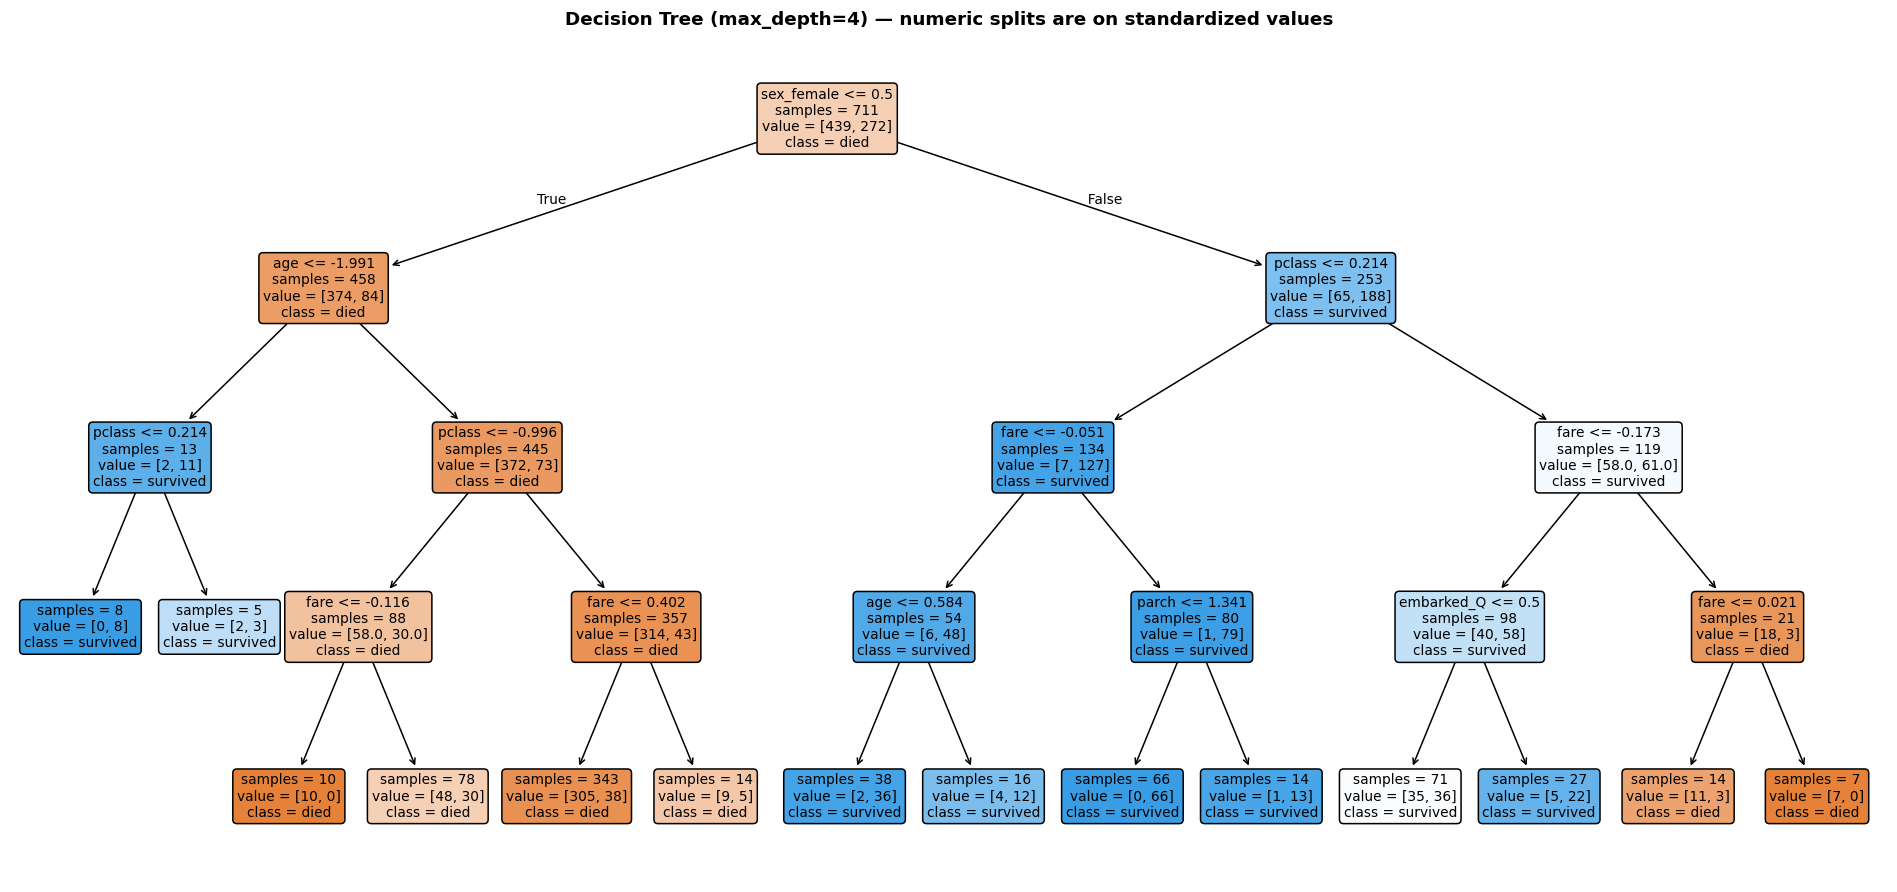

In [7]:
tree_pipe = fitted["Decision Tree"]
feature_names = [n.replace("num__", "").replace("cat__", "")
                 for n in tree_pipe.named_steps["preprocess"].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(tree_pipe.named_steps["model"], feature_names=feature_names, class_names=["died", "survived"],
          filled=True, rounded=True, impurity=False, proportion=False, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=4) — numeric splits are on standardized values")
save(fig, "09_decision_tree")
plt.show()

**Reading the tree.** The first split is on `sex_female` — the same finding as the EDA: sex matters most. For **women**, the next split is on class: `pclass <= 0.21` (standardized) means “1st or 2nd class”, and those women are predicted to survive. Among 3rd-class women the tree splits on `fare`: those with higher fares (about £23+, typically a shared ticket for a large family) are predicted to die, which matches the family-size finding in Chart 4. For **men**, the next split is on `age`: `age <= -1.99` standardized is roughly **3.5 years or younger**, and only those very young boys are predicted to survive. Every other male leaf predicts “died”. Thresholds are in standard-deviation units because the features were scaled first.

## 4. Full metric suite, side by side (Task 10)

In [8]:
def evaluate(pipe, X_eval, y_eval):
    pred = pipe.predict(X_eval)
    proba = pipe.predict_proba(X_eval)[:, 1]
    return {"Accuracy": accuracy_score(y_eval, pred),
            "Precision": precision_score(y_eval, pred),
            "Recall": recall_score(y_eval, pred),
            "F1": f1_score(y_eval, pred),
            "AUC": roc_auc_score(y_eval, proba)}

clf_results = pd.DataFrame({name: evaluate(p, X_test, y_test) for name, p in fitted.items()}).T.round(3)
clf_results

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.798,0.776,0.662,0.714,0.851
Random Forest,0.803,0.762,0.706,0.733,0.824


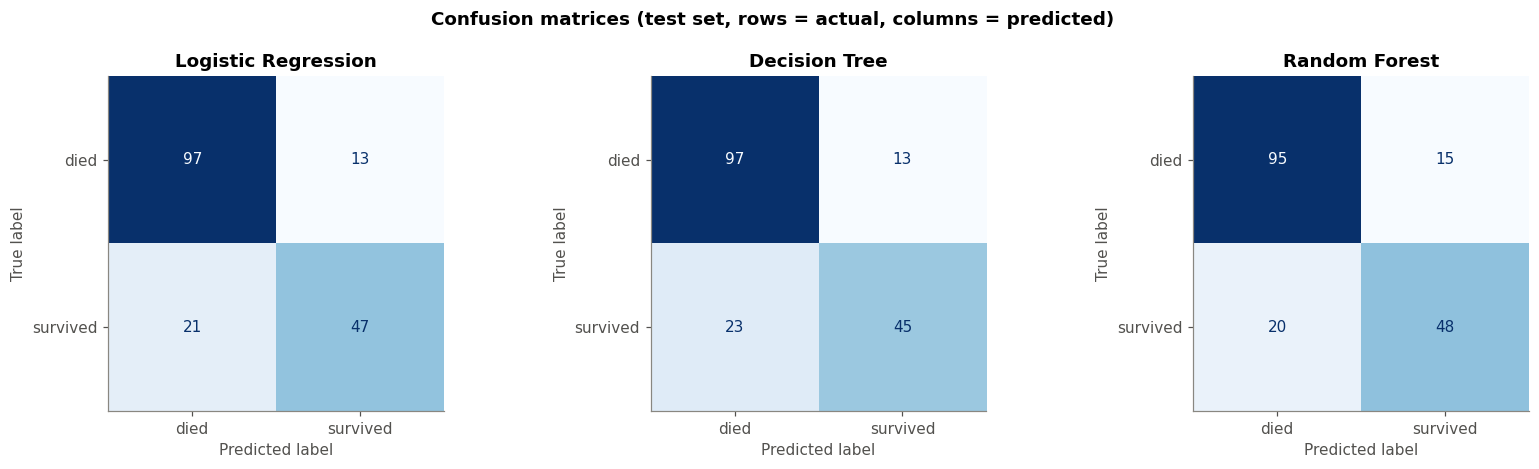

Logistic Regression  TN= 97  FP= 13  FN= 21  TP= 47
Decision Tree        TN= 97  FP= 13  FN= 23  TP= 45
Random Forest        TN= 95  FP= 15  FN= 20  TP= 48


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name); ax.grid(False)
fig.suptitle("Confusion matrices (test set, rows = actual, columns = predicted)", fontweight="bold")
fig.tight_layout()
save(fig, "10_confusion_matrices"); plt.show()

for name, pipe in fitted.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    print(f"{name:<20} TN={tn:3d}  FP={fp:3d}  FN={fn:3d}  TP={tp:3d}")

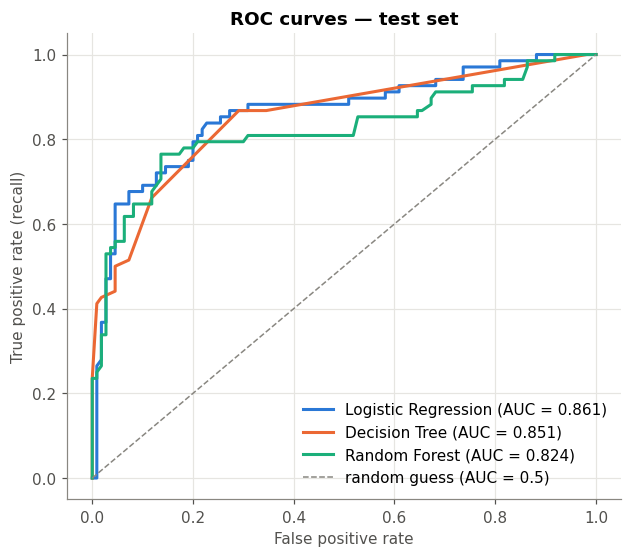

In [10]:
colors = {"Logistic Regression": "#2a78d6", "Decision Tree": "#eb6834", "Random Forest": "#1baf7a"}
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, pipe in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, linewidth=2, color=colors[name], label=f"{name} (AUC = {clf_results.loc[name, 'AUC']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#898781", linewidth=1, label="random guess (AUC = 0.5)")
ax.set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves — test set")
ax.legend(frameon=False, loc="lower right")
save(fig, "11_roc_curves"); plt.show()

**What the metrics say (test set, 178 passengers).**

* **Logistic Regression** — accuracy **0.809**, precision 0.783, recall 0.691, F1 0.734, and the **best AUC, 0.861**. A simple linear model already does well, because the main signals (sex, class) are close to linear.
* **Decision Tree** — accuracy 0.798, F1 0.714, AUC 0.851. It is easy to explain but has the lowest recall (0.662): it misses the most survivors (23 false negatives).
* **Random Forest (default settings)** — accuracy 0.803 and F1 0.733, but the lowest AUC (0.824). Its training accuracy is **0.985** against 0.803 on test: with unlimited depth it **memorises the training data (overfits)**. That is why it is tuned in §6.

All three models find about 70 % of the actual survivors (recall 0.66–0.71). When they predict “survived” they are right 76–78 % of the time (precision). The confusion matrices show the same thing: each model makes roughly 20 false negatives against 13–15 false positives, so its most common mistake is missing a survivor.

## 5. Imbalance handling: baseline vs `class_weight="balanced"` vs SMOTE (Task 11)

Class balance: **~62 % died / ~38 % survived** (numbers printed below). The minority class is “survived”.

Using **Logistic Regression** for all three variants:

* **(a) Baseline** — no special handling.
* **(b) `class_weight="balanced"`** — mistakes on the smaller class cost more during training.
* **(c) SMOTE** — creates synthetic survivor examples until the classes are 50/50. It sits *inside* an `imblearn` Pipeline, which applies resampling **only while fitting** (on the training data) and **never** when predicting on the test set, so no synthetic rows ever reach the test set.

In [11]:
print("Class balance (full data):")
print(y.value_counts().rename(index={0: "died (0)", 1: "survived (1)"}).to_string())
print((y.value_counts(normalize=True) * 100).round(1).rename(index={0: "died %", 1: "survived %"}).to_string())

variants = {
    "(a) Baseline": Pipeline([("preprocess", clone(preprocessor)),
                              ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "(b) class_weight='balanced'": Pipeline([("preprocess", clone(preprocessor)),
                              ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "(c) SMOTE (train fold only)": ImbPipeline([("preprocess", clone(preprocessor)),
                              ("smote", SMOTE(random_state=RANDOM_STATE)),
                              ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
}
imb_results = {}
for name, pipe in variants.items():
    pipe.fit(X_train, y_train)
    imb_results[name] = evaluate(pipe, X_test, y_test)
imb_results = pd.DataFrame(imb_results).T[["Precision", "Recall", "F1", "Accuracy", "AUC"]].round(3)

# Show that SMOTE balanced the TRAINING data only
Xt = variants["(c) SMOTE (train fold only)"].named_steps["preprocess"].transform(X_train)
_, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Xt, y_train)
print(f"\nTraining labels before SMOTE: {np.bincount(y_train)}  -> after SMOTE: {np.bincount(y_res)}")
print(f"Test labels (never resampled): {np.bincount(y_test)}")
imb_results

Class balance (full data):
survived
died (0)        549
survived (1)    340
survived
died %        61.8
survived %    38.2

Training labels before SMOTE: [439 272]  -> after SMOTE: [439 439]
Test labels (never resampled): [110  68]


,Precision,Recall,F1,Accuracy,AUC
(a) Baseline,0.783,0.691,0.734,0.809,0.861
(b) class_weight='balanced',0.718,0.750,0.734,0.792,0.861
(c) SMOTE (train fold only),0.735,0.735,0.735,0.798,0.867


**Conclusion — which imbalance strategy worked best?**

| Variant | Precision | Recall | F1 |
|---|---|---|---|
| (a) Baseline | **0.783** | 0.691 | 0.734 |
| (b) `class_weight='balanced'` | 0.718 | **0.750** | 0.734 |
| (c) SMOTE (train fold only) | 0.735 | 0.735 | **0.735** |

Both balancing methods did what they are designed to do: they made the model **predict “survived” more often**, trading precision for recall. `class_weight='balanced'` raised recall the most (0.691 → **0.750**, i.e. 4 more real survivors found out of 68) but lost the most precision (0.783 → 0.718). SMOTE landed in between, with precision = recall = 0.735, the best (by a hair) F1 of **0.735**, and also the best AUC (0.867).

**Best overall: SMOTE**, narrowly. It gives the most balanced precision/recall trade-off and the top F1 and AUC. The differences in F1 are tiny (0.734 vs 0.735), though, because the imbalance here is only mild (62/38), not extreme. The practical choice depends on the goal: if missing a real survivor is the costlier mistake, `class_weight='balanced'` is the better pick for its recall, and it is simpler (no synthetic data, no extra library). SMOTE was applied to the training fold only (272 → 439 survivors in training); the 178 test passengers were never resampled.

## 6. Hyperparameter tuning: GridSearchCV on the Random Forest + OOB score (Task 12)

* Grid: `n_estimators` ∈ {100, 300, 500}, `max_depth` ∈ {None, 4, 6, 8}, `max_features` ∈ {"sqrt", "log2", None} → 36 combinations × 5 folds = 180 fits.
* Cross-validation runs **on the training split only**, with stratified 5-fold CV. Because the preprocessing is inside the pipeline, it is re-fitted inside each fold as well.
* Scoring = **F1**, which balances precision and recall on the minority “survived” class.
* The estimator is built as `RandomForestClassifier(oob_score=True, ...)` so that `oob_score_` exists. OOB (“out-of-bag”) accuracy scores each training passenger using only the trees that did **not** see that passenger — a free, built-in validation score.

In [12]:
rf_pipe = Pipeline([("preprocess", clone(preprocessor)),
                    ("model", RandomForestClassifier(oob_score=True, bootstrap=True,
                                                     random_state=RANDOM_STATE, n_jobs=-1))])
param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 4, 6, 8],
    "model__max_features": ["sqrt", "log2", None],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring="f1", n_jobs=-1)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # small forests can warn that a few OOB rows were never left out
    grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
oob = best_rf.named_steps["model"].oob_score_

print("Best parameters      :", best_params)
print(f"Best mean CV F1      : {grid.best_score_:.3f}")
print(f"OOB score (accuracy) : {oob:.3f}   <- from RandomForestClassifier(oob_score=True, ...)")
clf_results.loc["Random Forest (tuned)"] = pd.Series(evaluate(best_rf, X_test, y_test)).round(3)
clf_results

Best parameters      : {'max_depth': 8, 'max_features': None, 'n_estimators': 300}
Best mean CV F1      : 0.772
OOB score (accuracy) : 0.831   <- from RandomForestClassifier(oob_score=True, ...)


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.798,0.776,0.662,0.714,0.851
Random Forest,0.803,0.762,0.706,0.733,0.824
Random Forest (tuned),0.826,0.814,0.706,0.756,0.842


In [13]:
res = pd.DataFrame(grid.cv_results_)
top = pd.DataFrame([{k.replace("model__", ""): str(v) for k, v in p.items()} for p in res["params"]])
top["mean CV F1"] = res["mean_test_score"].round(3)
top["std"] = res["std_test_score"].round(3)
top["rank"] = res["rank_test_score"]
top = top.sort_values("rank").head(8).reset_index(drop=True)
top

,max_depth,max_features,n_estimators,mean CV F1,std,rank
0,8,None,300,0.772,0.003,1
1,8,None,500,0.771,0.005,2
2,8,None,100,0.768,0.010,3
3,None,None,300,0.764,0.010,4
4,8,sqrt,100,0.763,0.037,5
5,8,log2,100,0.763,0.037,5
6,None,None,500,0.761,0.016,7
7,8,sqrt,500,0.761,0.029,8


**Tuning result.** The best combination was **`n_estimators=300`, `max_depth=8`, `max_features=None`** (every feature is considered at each split), with a mean cross-validated F1 of **0.772**. The tuned forest's **OOB score is 0.831**, which means about 83 % of training passengers were classified correctly by trees that never saw them. This is close to its test accuracy of **0.826**, so the OOB score was a trustworthy estimate of how the model does on new passengers.

The most important change was limiting **`max_depth` to 8**: the untuned forest (unlimited depth) overfit, while the depth-limited one generalises better. On the test set it improved on the default forest in accuracy (0.803 → **0.826**), precision (0.762 → **0.814**), F1 (0.733 → **0.756**) and AUC (0.824 → **0.842**). The three best settings all use `max_depth=8` and differ only in the number of trees (CV F1 0.768–0.772), so the result is stable rather than a lucky pick.

## 7. Regression side-task: predicting `fare` (Task 13)

* Target: `fare`. Features: every other passenger fact — `pclass`, `sex`, `age`, `sibsp`, `parch`, `embarked`, `survived`.
* Same train/test rows as the classifiers (same indices), same leak-free pipeline design, then `LinearRegression()`.
* **Adjusted R²** = 1 − (1 − R²)·(n − 1)/(n − p − 1), where n = test rows and p = number of features after one-hot encoding. It penalises adding features that do not really help.

In [14]:
REG_NUMERIC = ["pclass", "age", "sibsp", "parch", "survived"]
REG_CATEGORICAL = ["sex", "embarked"]
REG_FEATURES = REG_NUMERIC + REG_CATEGORICAL

Xr_train, Xr_test = df.loc[X_train.index, REG_FEATURES], df.loc[X_test.index, REG_FEATURES]
yr_train, yr_test = df.loc[X_train.index, "fare"], df.loc[X_test.index, "fare"]

reg_pipe = Pipeline([("preprocess", make_preprocessor(REG_NUMERIC, REG_CATEGORICAL)),
                     ("model", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

n = len(yr_test)
p = len(reg_pipe.named_steps["preprocess"].get_feature_names_out())
r2 = r2_score(yr_test, yr_pred)
reg_results = pd.Series({
    "MAE": mean_absolute_error(yr_test, yr_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, yr_pred)),
    "R2": r2,
    "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1),
}).round(3)
print(f"n (test rows) = {n}, p (features after encoding) = {p}")
reg_results.to_frame("Linear Regression (fare)")

n (test rows) = 178, p (features after encoding) = 10


,Linear Regression (fare)
MAE,19.753
RMSE,41.270
R2,0.347
Adjusted R2,0.308


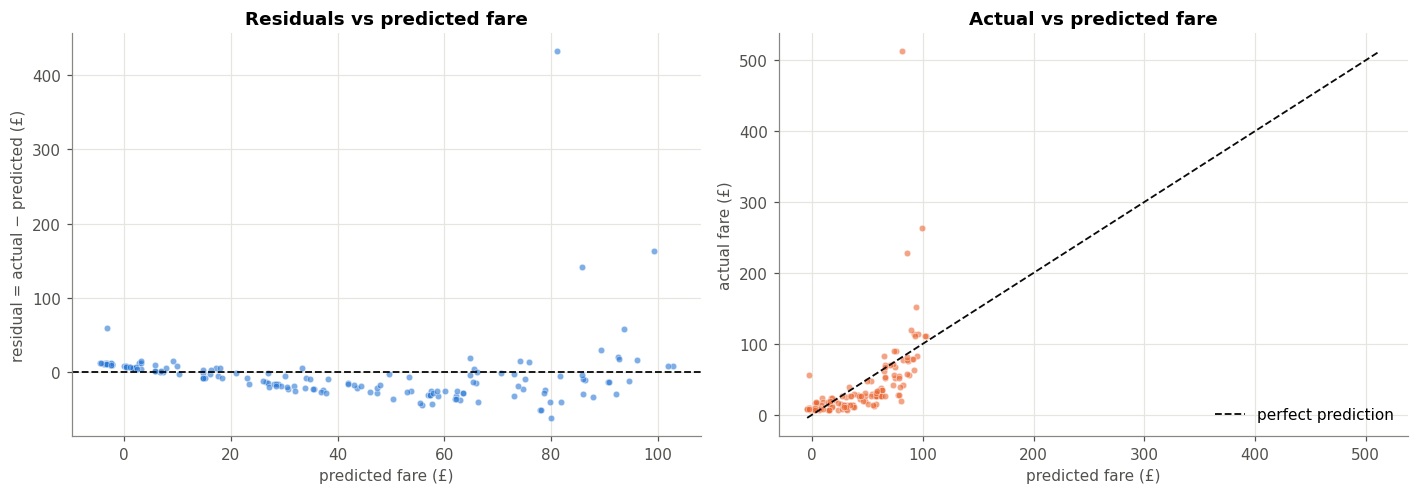

Residual std, lower half of predictions : £10.82
Residual std, upper half of predictions : £56.86
Ratio (upper / lower)                   : 5.3x
Correlation of |residual| with predicted: 0.32


In [15]:
residuals = yr_test - yr_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].scatter(yr_pred, residuals, s=18, alpha=0.6, color="#2a78d6", edgecolor="white", linewidth=0.4)
axes[0].axhline(0, color="#0b0b0b", linewidth=1.2, linestyle="--")
axes[0].set(xlabel="predicted fare (£)", ylabel="residual = actual − predicted (£)", title="Residuals vs predicted fare")
axes[1].scatter(yr_pred, yr_test, s=18, alpha=0.6, color="#eb6834", edgecolor="white", linewidth=0.4)
lim = [min(yr_pred.min(), 0), max(yr_test.max(), yr_pred.max())]
axes[1].plot(lim, lim, color="#0b0b0b", linewidth=1.2, linestyle="--", label="perfect prediction")
axes[1].set(xlabel="predicted fare (£)", ylabel="actual fare (£)", title="Actual vs predicted fare")
axes[1].legend(frameon=False)
fig.tight_layout()
save(fig, "12_regression_residuals"); plt.show()

# A simple numeric check of the spread: compare residual spread for low vs high predictions
low = residuals[yr_pred <= np.median(yr_pred)]
high = residuals[yr_pred > np.median(yr_pred)]
print(f"Residual std, lower half of predictions : £{low.std():.2f}")
print(f"Residual std, upper half of predictions : £{high.std():.2f}")
print(f"Ratio (upper / lower)                   : {high.std() / low.std():.1f}x")
print(f"Correlation of |residual| with predicted: {np.corrcoef(np.abs(residuals), yr_pred)[0, 1]:.2f}")

**Regression results.** MAE = **£19.75**, RMSE = **£41.27**, R² = **0.347**, Adjusted R² = **0.308**. The model explains only about a third of the variation in fare. That makes sense: class tells you the rough price range, but the exact fare depends on things the data does not contain (cabin, ticket shared by a group, booking agent). RMSE is about twice the MAE, which shows that a few very large errors dominate — the expensive 1st-class tickets. Adjusted R² is a little lower than R² because it penalises the 10 encoded features for a test set of only 178 rows.

**Heteroscedasticity: yes.** The residual plot is **not** an even, random band around zero. It forms a **funnel that widens to the right**: when the model predicts a low fare (3rd class) the residuals are tightly packed, but for higher predicted fares (1st class) they spread out enormously, with some errors above £200. The numbers confirm it: the residual standard deviation is **£10.82** for the lower half of predictions vs **£56.86** for the upper half — about **5.3× larger** — and |residual| grows with the predicted value (r = 0.32). So the error variance is not constant, which breaks a key linear-regression assumption. Because fare is heavily right-skewed, a common fix would be to model `log(fare)` instead.

## 8. Final model comparison table (Task 14)

Classification and regression metrics are on **different scales** and answer different questions, so they sit in **two separate column groups**. A dash (—) means “does not apply to this model type”.

In [16]:
clf_cols = pd.MultiIndex.from_product([["Classification metrics (target: survived, 0–1, higher is better)"],
                                       ["Accuracy", "Precision", "Recall", "F1", "AUC"]])
reg_cols = pd.MultiIndex.from_product([["Regression metrics (target: fare)"],
                                       ["MAE (£, lower better)", "RMSE (£, lower better)", "R²", "Adjusted R²"]])
table = pd.DataFrame("—", index=list(clf_results.index) + ["Linear Regression (fare)"],
                     columns=clf_cols.append(reg_cols), dtype=object)
for name in clf_results.index:
    table.loc[name, clf_cols] = clf_results.loc[name, ["Accuracy", "Precision", "Recall", "F1", "AUC"]].map("{:.3f}".format).values
table.loc["Linear Regression (fare)", reg_cols] = [f"{reg_results['MAE']:.2f}", f"{reg_results['RMSE']:.2f}",
                                                   f"{reg_results['R2']:.3f}", f"{reg_results['Adjusted R2']:.3f}"]
table

Classification metrics (target: survived, 0–1, higher is better)                                 \
                                                                                 Accuracy Precision Recall     F1    AUC   
Logistic Regression                                                   0.809                   0.783  0.691  0.734  0.861   
Decision Tree                                                         0.798                   0.776  0.662  0.714  0.851   
Random Forest                                                         0.803                   0.762  0.706  0.733  0.824   
Random Forest (tuned)                                                 0.826                   0.814  0.706  0.756  0.842   
Linear Regression (fare)                                                  —                       —      —      —      —   

                         Regression metrics (target: fare)                                            
                                     MAE (£, lower better) RMSE (£, lower better)     R² Adjusted R²  
Logistic Regression                                      —                      —      —           —  
Decision Tree                                            —                      —      —           —  
Random Forest                                            —                      —      —           —  
Random Forest (tuned)                                    —                      —      —           —  
Linear Regression (fare)                             19.75                  41.27  0.347       0.308

**Recommendation — deploy the tuned Random Forest.** It has the best test **accuracy (0.826)**, **precision (0.814)** and **F1 (0.756)** of the four classifiers. It was chosen by cross-validation on the training data only, and its **OOB score (0.831)** agrees closely with its test accuracy, so the result is not a lucky test split. Logistic Regression is a strong runner-up: it has the highest **AUC (0.861 vs 0.842)**, meaning it ranks passengers by risk slightly better, and it is easier to explain. If ranking quality or explainability mattered most, it would be the one to choose. With 178 test passengers, the 1.7-point accuracy gap between the two is only about 3 passengers, so the choice is close, and a larger test set or repeated cross-validation would make it firmer. The regression model (R² = 0.347) is reported separately and is not a candidate for this classification task.

## 9. Save the complete pipeline and reload it (Task 15)

The saved object is the **whole fitted `Pipeline`** — imputers, one-hot encoder, scaler **and** the model — so it accepts raw, unprocessed passenger data (text values like `"male"`, missing ages, etc.).

In [17]:
MODEL_PATH = Path("titanic_best_pipeline.joblib")
full_pipeline = best_rf                                  # the recommended model (see §8)
joblib.dump(full_pipeline, MODEL_PATH)
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.0f} KB)")
print("Steps:", [name for name, _ in full_pipeline.steps])

Saved titanic_best_pipeline.joblib  (2873 KB)
Steps: ['preprocess', 'model']


In [18]:
reloaded = joblib.load(MODEL_PATH)

# 1) The reloaded pipeline gives exactly the same predictions on the test set
same = (reloaded.predict(X_test) == full_pipeline.predict(X_test)).all()
print("Reloaded predictions identical to original on test set:", same)
print(f"Reloaded test accuracy: {accuracy_score(y_test, reloaded.predict(X_test)):.3f}")

# 2) It works end to end on brand-new RAW passengers (text categories, a missing age)
new_passengers = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29,     "sibsp": 0, "parch": 0, "fare": 100.0, "embarked": "C"},
    {"pclass": 3, "sex": "male",   "age": 25,     "sibsp": 0, "parch": 0, "fare": 7.25,  "embarked": "S"},
    {"pclass": 2, "sex": "male",   "age": 4,      "sibsp": 1, "parch": 1, "fare": 26.0,  "embarked": "S"},
    {"pclass": 3, "sex": "female", "age": np.nan, "sibsp": 0, "parch": 2, "fare": 15.5,  "embarked": "Q"},
])
out = new_passengers.copy()
out["P(survived)"] = reloaded.predict_proba(new_passengers)[:, 1].round(3)
out["prediction"] = np.where(reloaded.predict(new_passengers) == 1, "survived", "died")
out

Reloaded predictions identical to original on test set: True


Reloaded test accuracy: 0.826


,pclass,sex,age,sibsp,parch,fare,embarked,P(survived),prediction
0,1,female,29.0,0,0,100.00,C,1.000,survived
1,3,male,25.0,0,0,7.25,S,0.081,died
2,2,male,4.0,1,1,26.00,S,0.727,survived
3,3,female,NaN,0,2,15.50,Q,0.752,survived


The same check is available as a stand-alone script: `python predict_demo.py`.

**Done.** Data loaded once in `01_eda.ipynb` → same `titanic.csv` and cleaning rules here → leak-free pipelines → evaluated, balanced, tuned → saved as one reusable artifact.